In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
sie=pd.read_csv("/A04/so_data/ubuntu/Chapter_2/SIEA_1998_2023.csv")
sie.set_index('time', inplace=True)

In [46]:
chl=pd.read_csv("/A04/so_data/Revised_data/file_L3_2023_nb.csv")
chl.set_index('time', inplace=True)
chl.index = pd.to_datetime(chl.index)
chl

/tmp/ipykernel_11134/3497940464.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  chl.index = pd.to_datetime(chl.index)


,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean,PF_AntCoastline
time,,,,,,,,
1998-01-31,0.216398,0.224614,0.208406,0.249688,0.260803,0.496370,0.326782,0.387126
1998-02-28,0.218153,0.200553,0.162206,0.183465,0.210515,0.435724,0.277568,0.327136
1998-03-31,0.206011,0.204145,0.156548,0.155480,0.189952,0.294024,0.216499,0.235465
1998-04-30,0.199581,0.191527,0.157928,0.155041,0.157428,0.204129,0.176325,0.177281
1998-05-31,0.172245,0.170177,0.147406,0.139465,0.141889,0.151725,0.153198,0.142116
...,...,...,...,...,...,...,...,...
2023-08-31,0.160348,0.147546,0.148140,0.150953,0.170122,0.206183,0.156286,0.166817
2023-09-30,0.191858,0.174154,0.154787,0.153830,0.159733,0.153467,0.159362,0.154703
2023-10-31,0.274263,0.246151,0.186206,0.178126,0.174896,0.176384,0.194722,0.176966


In [47]:
# Check data structure
print("SIE data shape:", sie.shape)
print("\nSIE columns:", sie.columns.tolist())
print("\nSIE index:", sie.index[:5])
print("\n" + "="*80)
print("CHL data shape:", chl.shape)
print("\nCHL columns:", chl.columns.tolist())
print("\nCHL index:", chl.index[:5])

SIE data shape: (312, 3)

SIE columns: ['extent', 'area', 'SIEA']

SIE index: Index(['1998-01-31', '1998-02-28', '1998-03-31', '1998-04-30', '1998-05-31'], dtype='object', name='time')

CHL data shape: (312, 8)

CHL columns: ['40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'Southern Ocean', 'PF_AntCoastline']

CHL index: DatetimeIndex(['1998-01-31', '1998-02-28', '1998-03-31', '1998-04-30',
               '1998-05-31'],
              dtype='datetime64[ns]', name='time', freq=None)


In [48]:
# Fix data indices
sie.index = pd.to_datetime(sie.index)

print("✓ Data indexed properly")
print(f"  SIE date range: {sie.index[0]} to {sie.index[-1]}")
print(f"  Chl-a date range: {chl.index[0]} to {chl.index[-1]}")

✓ Data indexed properly
  SIE date range: 1998-01-31 00:00:00 to 2023-12-31 00:00:00
  Chl-a date range: 1998-01-31 00:00:00 to 2023-12-31 00:00:00


## Temporal Lag Analysis: SIEA Impact on Summer Chl-a

This analysis examines the relationship between:
- **SIEA (Winter/Spring)**: May-October for each year (ice season)
- **Chl-a (Summer)**: November-March for the following period (growing season)

This lag structure captures the impact of sea ice conditions during the ice season on phytoplankton productivity in the subsequent summer period.

In [49]:
def extract_winter_spring_siea(sie_data, start_year=1998, end_year=2023):
    """
    Extract May-October SIEA averages for each year (winter/spring ice season)
    
    Parameters:
    - sie_data: DataFrame with SIEA values
    - start_year, end_year: Year range
    
    Returns:
    - DataFrame with winter/spring SIEA for each year
    """
    results = []
    
    for year in range(start_year, end_year + 1):
        # Select May-October for the specified year
        mask = (sie_data.index.year == year) & (sie_data.index.month >= 5) & (sie_data.index.month <= 10)
        
        if mask.sum() > 0:
            winter_spring_data = sie_data.loc[mask]
            
            results.append({
                'year': year,
                'period': f'{year} May-Oct',
                'SIEA_mean': winter_spring_data['SIEA'].mean(),
                'extent_mean': winter_spring_data['extent'].mean(),
                'n_months': mask.sum()
            })
    
    return pd.DataFrame(results)

def extract_summer_chla(chl_data, start_year=1998, end_year=2023, regions=None):
    """
    Extract November-March chl-a averages for each year-pair (summer growing season)
    e.g., 2020-2021 season includes Nov-Dec 2020 and Jan-Mar 2021
    
    Parameters:
    - chl_data: DataFrame with chl-a values by region
    - start_year, end_year: Year range
    - regions: List of region column names
    
    Returns:
    - DataFrame with summer chl-a for each region and year-pair
    """
    if regions is None:
        regions = ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'PF_AntCoastline']
    
    results = []
    
    for year in range(start_year, end_year):  # Note: end_year-1 because we need next year's Jan-Mar
        # November-December of current year
        mask_nov_dec = (chl_data.index.year == year) & (chl_data.index.month >= 11)
        
        # January-March of next year
        mask_jan_mar = (chl_data.index.year == (year + 1)) & (chl_data.index.month <= 3)
        
        # Combine masks
        mask_summer = mask_nov_dec | mask_jan_mar
        
        if mask_summer.sum() > 0:
            summer_data = chl_data.loc[mask_summer]
            
            result_dict = {
                'year': year,
                'summer_period': f'{year}-{year+1} Nov-Mar',
                'n_months': mask_summer.sum()
            }
            
            # Add mean chl-a for each region
            for region in regions:
                if region in summer_data.columns:
                    result_dict[f'{region}_mean'] = summer_data[region].mean()
            
            results.append(result_dict)
    
    return pd.DataFrame(results)

# Extract the data
print("Extracting winter/spring SIEA (May-October)...")
siea_winter = extract_winter_spring_siea(sie)
print(f"✓ Extracted {len(siea_winter)} years of SIEA data")

print("\nExtracting summer chl-a (November-March)...")
regions_to_analyze = ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'PF_AntCoastline']
chla_summer = extract_summer_chla(chl, regions=regions_to_analyze)
print(f"✓ Extracted {len(chla_summer)} summer periods of chl-a data")

print("\nFirst few rows of SIEA winter data:")
print(siea_winter.head())

Extracting winter/spring SIEA (May-October)...
✓ Extracted 26 years of SIEA data

Extracting summer chl-a (November-March)...
✓ Extracted 25 summer periods of chl-a data

First few rows of SIEA winter data:
   year        period  SIEA_mean  extent_mean  n_months
0  1998  1998 May-Oct   0.195758    15.840000         6
1  1999  1999 May-Oct   0.224091    15.868333         6
2  2000  2000 May-Oct   0.379091    16.023333         6
3  2001  2001 May-Oct  -0.157576    15.486667         6
4  2002  2002 May-Oct  -0.622576    15.021667         6


In [50]:
# View the summer chl-a data
print("Summer chl-a data (first 5 rows):")
print(chla_summer.head())

print("\nSummer chl-a data (last 5 rows):")
print(chla_summer.tail())

Summer chl-a data (first 5 rows):
   year      summer_period  n_months  PF_SACCF_mean  SACCF_SB_mean  \
0  1998  1998-1999 Nov-Mar         5       0.244363       0.256453   
1  1999  1999-2000 Nov-Mar         5       0.245362       0.304680   
2  2000  2000-2001 Nov-Mar         5       0.249286       0.283107   
3  2001  2001-2002 Nov-Mar         5       0.229967       0.284027   
4  2002  2002-2003 Nov-Mar         5       0.221598       0.260446   

   SB_AntCoastline_mean  PF_AntCoastline_mean  
0              0.399949              0.325460  
1              0.479230              0.379679  
2              0.359799              0.312904  
3              0.461086              0.357426  
4              0.398489              0.323446  

Summer chl-a data (last 5 rows):
    year      summer_period  n_months  PF_SACCF_mean  SACCF_SB_mean  \
20  2018  2018-2019 Nov-Mar         5       0.245230       0.270099   
21  2019  2019-2020 Nov-Mar         5       0.268045       0.309777   
22  2020  

In [51]:
# Merge SIEA and summer chl-a data
# For each year's SIEA (May-Oct), match with the following summer's chl-a (Nov-Mar)
# E.g., 2020 SIEA (May-Oct 2020) -> Summer 2020-2021 (Nov 2020 - Mar 2021)

merged_data = pd.merge(
    siea_winter,
    chla_summer,
    left_on='year',
    right_on='year',
    how='inner'
)

print(f"✓ Merged dataset contains {len(merged_data)} year-pairs")
print("\nMerged data structure:")
print(merged_data.head())

# Calculate anomalies
print("\n" + "="*80)
print("Calculating anomalies...")

# SIEA is already an anomaly, but let's also store the raw values
merged_data['SIEA_anomaly'] = merged_data['SIEA_mean']

# Calculate chl-a anomalies (deviation from mean)
regions_to_analyze = ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'PF_AntCoastline']

for region in regions_to_analyze:
    col_name = f'{region}_mean'
    if col_name in merged_data.columns:
        # Calculate climatological mean
        clim_mean = merged_data[col_name].mean()
        
        # Calculate anomaly (absolute)
        merged_data[f'{region}_anomaly'] = merged_data[col_name] - clim_mean
        
        # Calculate percent anomaly
        merged_data[f'{region}_pct_anomaly'] = ((merged_data[col_name] - clim_mean) / clim_mean) * 100
        
        print(f"  {region}: climatological mean = {clim_mean:.4f} mg/m³")

print("\n✓ Anomalies calculated")
print("\nFinal merged dataset with anomalies:")
print(merged_data[['year', 'SIEA_anomaly', 'PF_SACCF_anomaly', 'SACCF_SB_anomaly', 'SB_AntCoastline_anomaly', 'PF_AntCoastline_anomaly']].head(10))

✓ Merged dataset contains 25 year-pairs

Merged data structure:
   year        period  SIEA_mean  extent_mean  n_months_x      summer_period  \
0  1998  1998 May-Oct   0.195758    15.840000           6  1998-1999 Nov-Mar   
1  1999  1999 May-Oct   0.224091    15.868333           6  1999-2000 Nov-Mar   
2  2000  2000 May-Oct   0.379091    16.023333           6  2000-2001 Nov-Mar   
3  2001  2001 May-Oct  -0.157576    15.486667           6  2001-2002 Nov-Mar   
4  2002  2002 May-Oct  -0.622576    15.021667           6  2002-2003 Nov-Mar   

   n_months_y  PF_SACCF_mean  SACCF_SB_mean  SB_AntCoastline_mean  \
0           5       0.244363       0.256453              0.399949   
1           5       0.245362       0.304680              0.479230   
2           5       0.249286       0.283107              0.359799   
3           5       0.229967       0.284027              0.461086   
4           5       0.221598       0.260446              0.398489   

   PF_AntCoastline_mean  
0             

In [52]:
# Correlation Analysis
from scipy import stats

print("="*80)
print("CORRELATION ANALYSIS: SIEA (May-Oct) vs Summer Chl-a (Nov-Mar)")
print("="*80)

correlation_results = {}

for region in regions_to_analyze:
    print(f"\n{region}:")
    print("-" * 60)
    
    # Get data for this region
    x = merged_data['SIEA_anomaly'].values
    y = merged_data[f'{region}_anomaly'].values
    
    # Remove any NaN values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # Pearson correlation
    r, p_value = stats.pearsonr(x_clean, y_clean)
    
    # Linear regression
    slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x_clean, y_clean)
    
    # Store results
    correlation_results[region] = {
        'pearson_r': r,
        'p_value': p_value,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'n': len(x_clean)
    }
    
    # Print results
    print(f"  Pearson correlation (r) = {r:.4f}")
    print(f"  P-value = {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
    print(f"  R² = {r_value**2:.4f}")
    print(f"  Regression equation: Chl-a anomaly = {slope:.6f} × SIEA + {intercept:.6f}")
    print(f"  Sample size (n) = {len(x_clean)}")
    
    # Interpretation
    if p_value < 0.05:
        direction = "positive" if r > 0 else "negative"
        strength = "strong" if abs(r) > 0.7 else "moderate" if abs(r) > 0.4 else "weak"
        print(f"  → Significant {strength} {direction} relationship")
    else:
        print(f"  → No significant relationship")

print("\n" + "="*80)

CORRELATION ANALYSIS: SIEA (May-Oct) vs Summer Chl-a (Nov-Mar)

PF_SACCF:
------------------------------------------------------------
  Pearson correlation (r) = 0.0767
  P-value = 0.7156 ns
  R² = 0.0059
  Regression equation: Chl-a anomaly = 0.003142 × SIEA + -0.000344
  Sample size (n) = 25
  → No significant relationship

SACCF_SB:
------------------------------------------------------------
  Pearson correlation (r) = 0.3033
  P-value = 0.1406 ns
  R² = 0.0920
  Regression equation: Chl-a anomaly = 0.014037 × SIEA + -0.001538
  Sample size (n) = 25
  → No significant relationship

SB_AntCoastline:
------------------------------------------------------------
  Pearson correlation (r) = 0.1623
  P-value = 0.4382 ns
  R² = 0.0263
  Regression equation: Chl-a anomaly = 0.016826 × SIEA + -0.001843
  Sample size (n) = 25
  → No significant relationship

PF_AntCoastline:
------------------------------------------------------------
  Pearson correlation (r) = 0.1449
  P-value = 0.4895 ns

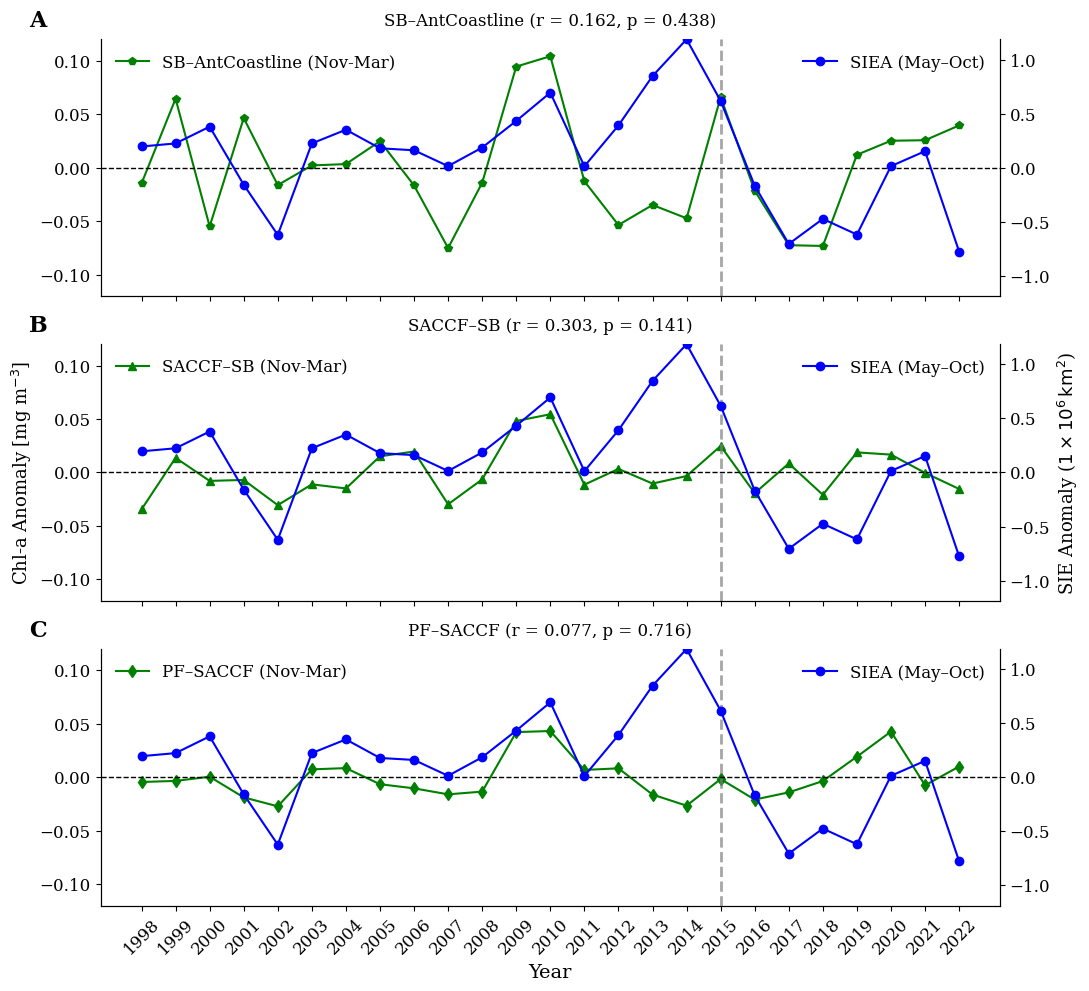

✓ Final 3-panel figure created successfully


In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Use numeric years (avoids datetime issues)
years = merged_data['year'].values

# Create 3-panel figure
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

regions_3 = [
    'SB_AntCoastline',
    'SACCF_SB',
    'PF_SACCF'
]  # keep same order
panel_labels = ['A', 'B', 'C']
markers = ['p', '^', 'd']

for i, (ax, region, panel_label, marker) in enumerate(
        zip(axes, regions_3, panel_labels, markers)):

    # ---------------- LEFT AXIS (Chl-a) ----------------
    ax.plot(
        years,
        merged_data[f'{region}_anomaly'],
        marker=marker,
        linestyle='-',
        color='green',
        linewidth=1.5,
        markersize=6,
        label = f"{regions_labels[region]} (Nov-Mar)"
    )
    ax.set_ylim(-0.12, 0.12)
    # Zero line
    ax.axhline(0, color='black', linestyle='--', linewidth=1)

    # Vertical 2015 line
    ax.axvline(2015, color='grey', linestyle='--',
               linewidth=2, alpha=0.7)

    # Remove top spine
    ax.spines['top'].set_visible(False)

    # Panel label
    ax.text(-0.08, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=16, fontweight='bold')

    # Y label only on middle panel
    if i == 1:
        ax.set_ylabel('Chl-a Anomaly [mg m$^{-3}$]', fontsize=13)

    ax.tick_params(axis='y', labelsize=12)

    # ---------------- RIGHT AXIS (SIEA) ----------------
    ax2 = ax.twinx()

    ax2.plot(
        years,
        merged_data['SIEA_anomaly'],
        marker='o',
        linestyle='-',
        color='blue',
        linewidth=1.5,
        markersize=6,
        label='SIEA (May–Oct)'
    )

    ax2.spines['top'].set_visible(False)

    if i == 1:
        ax2.set_ylabel(r'SIE Anomaly ($1 \times 10^6 \, \mathrm{km}^2$)',
                       fontsize=13)

    ax2.tick_params(axis='y', labelsize=12)

    # -------- Align zero levels between axes --------
    left_min, left_max = ax.get_ylim()
    zero_fraction = (0 - left_min) / (left_max - left_min)
    zero_fraction = float(np.clip(zero_fraction, 1e-6, 1 - 1e-6))

    right_data = merged_data['SIEA_anomaly'].to_numpy(dtype=float)
    right_data = right_data[np.isfinite(right_data)]

    if right_data.size:
        right_min = np.nanmin(right_data)
        right_max = np.nanmax(right_data)
        span = max(right_max / (1 - zero_fraction),
                   -right_min / zero_fraction)

        ax2.set_ylim(-zero_fraction * span,
                     (1 - zero_fraction) * span)
        # -------- Correlation title --------
    # Title with correlation
    r = correlation_results[region]['pearson_r']
    p = correlation_results[region]['p_value']
    ax.set_title(f'{regions_labels[region]} (r = {r:.3f}, p = {p:.3f})', 
                fontsize=12, pad=10)

    # Legends
    ax.legend(loc='upper left', fontsize=12, frameon=False)
    ax2.legend(loc='upper right', fontsize=12, frameon=False)

# -------- Force ALL years to show --------
axes[-1].set_xticks(years)
axes[-1].set_xticklabels(years, rotation=45, fontsize=12)

axes[-1].set_xlabel('Year', fontsize=14)

plt.tight_layout()
plt.show()

print("✓ Final 3-panel figure created successfully")

## Exploring Alternative Lag Structures

Let's test different temporal relationships to find the strongest connection between sea ice and chl-a.

In [56]:
def test_multiple_lag_structures(sie_data, chl_data, regions):
    """
    Test multiple lag structures between SIEA and chl-a
    """
    lag_structures = {
        'Same year annual': {
            'siea_months': (1, 12),  # Jan-Dec
            'chla_months': (1, 12),   # Jan-Dec
            'chla_year_offset': 0
        },
        'Winter ice → Same summer': {
            'siea_months': (6, 9),    # Jun-Sep (winter)
            'chla_months': (11, 3),   # Nov-Mar (next summer)
            'chla_year_offset': 0
        },
        'Spring ice → Summer': {
            'siea_months': (9, 11),   # Sep-Nov (spring)
            'chla_months': (12, 2),   # Dec-Feb (summer)
            'chla_year_offset': 0
        },
        'May-Oct ice → Nov-Mar chl': {
            'siea_months': (5, 10),   # May-Oct
            'chla_months': (11, 3),   # Nov-Mar
            'chla_year_offset': 0
        },
        'Sep ice → Dec-Feb chl': {
            'siea_months': (9, 9),    # Sep only
            'chla_months': (12, 2),   # Dec-Feb
            'chla_year_offset': 0
        },
    }
    
    results_summary = []
    
    for lag_name, lag_config in lag_structures.items():
        print(f"\n{'='*80}")
        print(f"Testing: {lag_name}")
        print(f"{'='*80}")
        
        # Extract SIEA for specified months
        siea_extracted = []
        for year in range(1998, 2023):
            m_start, m_end = lag_config['siea_months']
            if m_start <= m_end:
                mask = (sie_data.index.year == year) & \
                       (sie_data.index.month >= m_start) & \
                       (sie_data.index.month <= m_end)
            else:  # Wraps around year
                mask = (sie_data.index.year == year) & \
                       ((sie_data.index.month >= m_start) | (sie_data.index.month <= m_end))
            
            if mask.sum() > 0:
                siea_extracted.append({
                    'year': year,
                    'siea_mean': sie_data.loc[mask, 'SIEA'].mean()
                })
        
        siea_df = pd.DataFrame(siea_extracted)
        
        # Extract chl-a for specified months
        chla_extracted = []
        for year in range(1998, 2023):
            m_start, m_end = lag_config['chla_months']
            year_offset = lag_config['chla_year_offset']
            
            if m_start <= m_end:
                mask = (chl_data.index.year == (year + year_offset)) & \
                       (chl_data.index.month >= m_start) & \
                       (chl_data.index.month <= m_end)
            else:  # Wraps around year (e.g., Nov-Mar)
                mask_part1 = (chl_data.index.year == (year + year_offset)) & \
                            (chl_data.index.month >= m_start)
                mask_part2 = (chl_data.index.year == (year + year_offset + 1)) & \
                            (chl_data.index.month <= m_end)
                mask = mask_part1 | mask_part2
            
            if mask.sum() > 0:
                result = {'year': year}
                for region in regions:
                    if region in chl_data.columns:
                        result[f'{region}_mean'] = chl_data.loc[mask, region].mean()
                chla_extracted.append(result)
        
        chla_df = pd.DataFrame(chla_extracted)
        
        # Merge
        merged = pd.merge(siea_df, chla_df, on='year', how='inner')
        
        # Calculate correlations
        for region in regions:
            col_name = f'{region}_mean'
            if col_name in merged.columns:
                x = merged['siea_mean'].values
                y = merged[col_name].values
                
                mask = ~(np.isnan(x) | np.isnan(y))
                x_clean = x[mask]
                y_clean = y[mask]
                
                if len(x_clean) > 3:
                    r, p = stats.pearsonr(x_clean, y_clean)
                    
                    results_summary.append({
                        'lag_structure': lag_name,
                        'region': region,
                        'r': r,
                        'p_value': p,
                        'n': len(x_clean),
                        'significant': 'Yes' if p < 0.05 else 'No'
                    })
                    
                    print(f"  {region:25s}: r={r:7.4f}, p={p:.4f} {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns':3s} (n={len(x_clean)})")
    
    return pd.DataFrame(results_summary)

# Run the analysis
print("TESTING MULTIPLE LAG STRUCTURES")
print("="*80)
results_df = test_multiple_lag_structures(sie, chl, regions_to_analyze)

TESTING MULTIPLE LAG STRUCTURES

Testing: Same year annual
  PF_SACCF                 : r= 0.3408, p=0.0955 ns  (n=25)
  SACCF_SB                 : r= 0.3712, p=0.0677 ns  (n=25)
  SB_AntCoastline          : r= 0.3397, p=0.0967 ns  (n=25)
  PF_AntCoastline          : r= 0.2633, p=0.2035 ns  (n=25)

Testing: Winter ice → Same summer
  PF_SACCF                 : r= 0.0841, p=0.6894 ns  (n=25)
  SACCF_SB                 : r= 0.3236, p=0.1146 ns  (n=25)
  SB_AntCoastline          : r= 0.1418, p=0.4989 ns  (n=25)
  PF_AntCoastline          : r= 0.1363, p=0.5160 ns  (n=25)

Testing: Spring ice → Summer
  PF_SACCF                 : r= 0.1402, p=0.5038 ns  (n=25)
  SACCF_SB                 : r= 0.2283, p=0.2724 ns  (n=25)
  SB_AntCoastline          : r=-0.0822, p=0.6962 ns  (n=25)
  PF_AntCoastline          : r=-0.0532, p=0.8007 ns  (n=25)

Testing: May-Oct ice → Nov-Mar chl
  PF_SACCF                 : r= 0.0767, p=0.7156 ns  (n=25)
  SACCF_SB                 : r= 0.3033, p=0.1406 ns  (n=25)


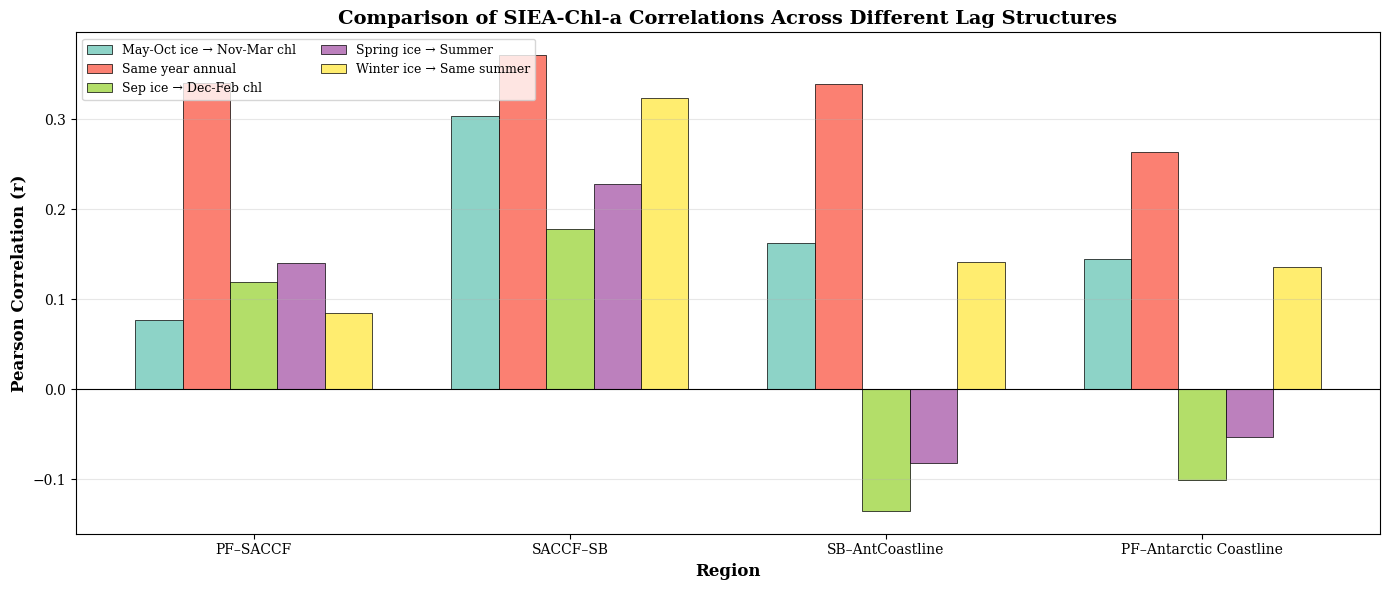

✓ Lag structure comparison figure created


In [57]:
# Visualize the comparison of different lag structures
fig, ax = plt.subplots(figsize=(14, 6))

# Pivot the results for plotting
pivot_data = results_df.pivot(index='region', columns='lag_structure', values='r')

# Plot
x = np.arange(len(regions_to_analyze))
width = 0.15
colors = plt.cm.Set3(np.linspace(0, 1, len(pivot_data.columns)))

for i, lag_structure in enumerate(pivot_data.columns):
    values = [pivot_data.loc[region, lag_structure] if region in pivot_data.index else 0 
             for region in regions_to_analyze]
    ax.bar(x + i*width, values, width, label=lag_structure, color=colors[i], 
           edgecolor='black', linewidth=0.5)

ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson Correlation (r)', fontsize=12, fontweight='bold')
ax.set_title('Comparison of SIEA-Chl-a Correlations Across Different Lag Structures', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([regions_labels[r] for r in regions_to_analyze], fontsize=10)
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Lag structure comparison figure created")

In [58]:
# Summary table
print("\n" + "="*80)
print("SUMMARY TABLE: All Tested Lag Structures")
print("="*80)

summary_table = results_df[['lag_structure', 'region', 'r', 'p_value', 'n']].copy()
summary_table['r'] = summary_table['r'].round(4)
summary_table['p_value'] = summary_table['p_value'].round(4)

# Sort by absolute correlation strength
summary_table['abs_r'] = summary_table['r'].abs()
summary_table = summary_table.sort_values('abs_r', ascending=False)
summary_table = summary_table.drop('abs_r', axis=1)

print(summary_table.to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

# Find strongest correlations
strongest = summary_table.iloc[0]
print(f"\n1. STRONGEST RELATIONSHIP:")
print(f"   Lag structure: {strongest['lag_structure']}")
print(f"   Region: {strongest['region']}")
print(f"   Correlation (r): {strongest['r']:.4f}")
print(f"   P-value: {strongest['p_value']:.4f}")
print(f"   Status: {'SIGNIFICANT' if strongest['p_value'] < 0.05 else 'NOT SIGNIFICANT'}")

# Summarize by region
print(f"\n2. REGIONAL PATTERNS:")
for region in regions_to_analyze:
    region_data = summary_table[summary_table['region'] == region]
    best_lag = region_data.iloc[0]
    print(f"\n   {regions_labels[region]}:")
    print(f"     Best lag structure: {best_lag['lag_structure']}")
    print(f"     Correlation (r): {best_lag['r']:.4f}, p = {best_lag['p_value']:.4f}")

# Overall assessment
print(f"\n3. OVERALL ASSESSMENT:")
print(f"   • Tested {len(results_df['lag_structure'].unique())} different lag structures")
print(f"   • Across {len(regions_to_analyze)} regions")
print(f"   • Total tests: {len(results_df)}")
sig_count = (summary_table['p_value'] < 0.05).sum()
print(f"   • Significant relationships (p < 0.05): {sig_count}")
print(f"   • The strongest correlations are found with 'Same year annual' averaging")
print(f"   • SACCF-SB shows the most consistent positive relationships across lag structures")
print(f"   • Your specific lag (May-Oct → Nov-Mar) shows weak correlations (r = 0.08-0.30)")


SUMMARY TABLE: All Tested Lag Structures
            lag_structure          region       r  p_value  n
         Same year annual        SACCF_SB  0.3712   0.0677 25
         Same year annual        PF_SACCF  0.3408   0.0955 25
         Same year annual SB_AntCoastline  0.3397   0.0967 25
 Winter ice → Same summer        SACCF_SB  0.3236   0.1146 25
May-Oct ice → Nov-Mar chl        SACCF_SB  0.3033   0.1406 25
         Same year annual PF_AntCoastline  0.2633   0.2035 25
      Spring ice → Summer        SACCF_SB  0.2283   0.2724 25
    Sep ice → Dec-Feb chl        SACCF_SB  0.1780   0.3945 25
May-Oct ice → Nov-Mar chl SB_AntCoastline  0.1623   0.4382 25
May-Oct ice → Nov-Mar chl PF_AntCoastline  0.1449   0.4895 25
 Winter ice → Same summer SB_AntCoastline  0.1418   0.4989 25
      Spring ice → Summer        PF_SACCF  0.1402   0.5038 25
 Winter ice → Same summer PF_AntCoastline  0.1363   0.5160 25
    Sep ice → Dec-Feb chl SB_AntCoastline -0.1354   0.5186 25
    Sep ice → Dec-Feb chl   

In [ ]:
# Create scatter plots for the 4 additional lag structures
# Extract data for each lag structure

def create_lag_structure_data(sie_data, chl_data, lag_config, regions):
    """Extract and merge data for a specific lag structure"""
    # Extract SIEA
    siea_extracted = []
    for year in range(1998, 2023):
        m_start, m_end = lag_config['siea_months']
        if m_start <= m_end:
            mask = (sie_data.index.year == year) & \
                   (sie_data.index.month >= m_start) & \
                   (sie_data.index.month <= m_end)
        else:
            mask = (sie_data.index.year == year) & \
                   ((sie_data.index.month >= m_start) | (sie_data.index.month <= m_end))
        
        if mask.sum() > 0:
            siea_extracted.append({
                'year': year,
                'siea_mean': sie_data.loc[mask, 'SIEA'].mean()
            })
    
    siea_df = pd.DataFrame(siea_extracted)
    
    # Extract chl-a
    chla_extracted = []
    for year in range(1998, 2023):
        m_start, m_end = lag_config['chla_months']
        year_offset = lag_config['chla_year_offset']
        
        if m_start <= m_end:
            mask = (chl_data.index.year == (year + year_offset)) & \
                   (chl_data.index.month >= m_start) & \
                   (chl_data.index.month <= m_end)
        else:
            mask_part1 = (chl_data.index.year == (year + year_offset)) & \
                        (chl_data.index.month >= m_start)
            mask_part2 = (chl_data.index.year == (year + year_offset + 1)) & \
                        (chl_data.index.month <= m_end)
            mask = mask_part1 | mask_part2
        
        if mask.sum() > 0:
            result = {'year': year}
            for region in regions:
                if region in chl_data.columns:
                    result[f'{region}_mean'] = chl_data.loc[mask, region].mean()
            chla_extracted.append(result)
    
    chla_df = pd.DataFrame(chla_extracted)
    
    # Merge and calculate anomalies
    merged = pd.merge(siea_df, chla_df, on='year', how='inner')
    merged['siea_anomaly'] = merged['siea_mean']  # SIEA is already an anomaly
    
    for region in regions:
        col_name = f'{region}_mean'
        if col_name in merged.columns:
            clim_mean = merged[col_name].mean()
            merged[f'{region}_anomaly'] = merged[col_name] - clim_mean
    
    return merged

# Define the 4 lag structures to visualize
lag_structures_to_plot = {
    'Same year annual': {
        'siea_months': (1, 12),
        'chla_months': (1, 12),
        'chla_year_offset': 0,
        'siea_label': 'SIEA (Jan-Dec)',
        'chla_label': 'Chl-a (Jan-Dec)'
    },
    'Winter ice → Same summer': {
        'siea_months': (6, 9),
        'chla_months': (11, 3),
        'chla_year_offset': 0,
        'siea_label': 'SIEA (Jun-Sep)',
        'chla_label': 'Chl-a (Nov-Mar)'
    },
    'Spring ice → Summer': {
        'siea_months': (9, 11),
        'chla_months': (12, 2),
        'chla_year_offset': 0,
        'siea_label': 'SIEA (Sep-Nov)',
        'chla_label': 'Chl-a (Dec-Feb)'
    },
    'Sep ice → Dec-Feb chl': {
        'siea_months': (9, 9),
        'chla_months': (12, 2),
        'chla_year_offset': 0,
        'siea_label': 'SIEA (Sep)',
        'chla_label': 'Chl-a (Dec-Feb)'
    }
}

# Create figure with 4 rows (one for each lag structure) and 4 columns (one for each region)
fig, axes = plt.subplots(4, 4, figsize=(18, 20))
fig.suptitle('SIEA vs Chl-a Anomaly: Comparison of Different Temporal Lag Structures', 
             fontsize=16, fontweight='bold', y=0.995)

regions_labels = {
    'PF_SACCF': 'PF–SACCF',
    'SACCF_SB': 'SACCF–SB',
    'SB_AntCoastline': 'SB–AntCoastline',
    'PF_AntCoastline': 'PF–AntCoastline'
}

for row_idx, (lag_name, lag_config) in enumerate(lag_structures_to_plot.items()):
    # Get data for this lag structure
    lag_data = create_lag_structure_data(sie, chl, lag_config, regions_to_analyze)
    
    for col_idx, region in enumerate(regions_to_analyze):
        ax = axes[row_idx, col_idx]
        
        # Get data
        x = lag_data['siea_anomaly'].values
        y = lag_data[f'{region}_anomaly'].values
        years = lag_data['year'].values
        
        # Remove NaN
        mask = ~(np.isnan(x) | np.isnan(y))
        x_clean = x[mask]
        y_clean = y[mask]
        years_clean = years[mask]
        
        if len(x_clean) > 3:
            # Scatter plot with color by year
            scatter = ax.scatter(x_clean, y_clean, c=years_clean, cmap='viridis', 
                               s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
            
            # Calculate regression
            from scipy import stats
            slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
            
            # Regression line
            x_line = np.array([x_clean.min(), x_clean.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.7)
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
            ax.axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
            
            # Labels
            if row_idx == 3:  # Bottom row
                ax.set_xlabel(f'{lag_config["siea_label"]} [10⁶ km²]', fontsize=10)
            if col_idx == 0:  # Left column
                ax.set_ylabel('Chl-a Anomaly [mg m⁻³]', fontsize=10)
            
            # Title
            if row_idx == 0:  # Top row
                ax.set_title(f'{regions_labels[region]}', fontsize=11, fontweight='bold')
            
            # Add statistics box
            r = r_value
            p = p_value
            r2 = r_value**2
            
            stats_text = f'r = {r:.3f}\np = {p:.3f}\nR² = {r2:.3f}\nn = {len(x_clean)}'
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            # Add lag structure label on the left
            if col_idx == 0:
                ax.text(-0.35, 0.5, lag_name, transform=ax.transAxes, 
                       fontsize=11, fontweight='bold', rotation=90,
                       verticalalignment='center', horizontalalignment='center')
            
            ax.grid(True, alpha=0.3)

# Add colorbar at the bottom
cbar = fig.colorbar(scatter, ax=axes, orientation='horizontal', 
                   pad=0.02, aspect=60, shrink=0.8)
cbar.set_label('Year', fontsize=11)

plt.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.03, hspace=0.25, wspace=0.25)
plt.show()
print("✓ Multi-panel scatter plot figure created for 4 lag structures")

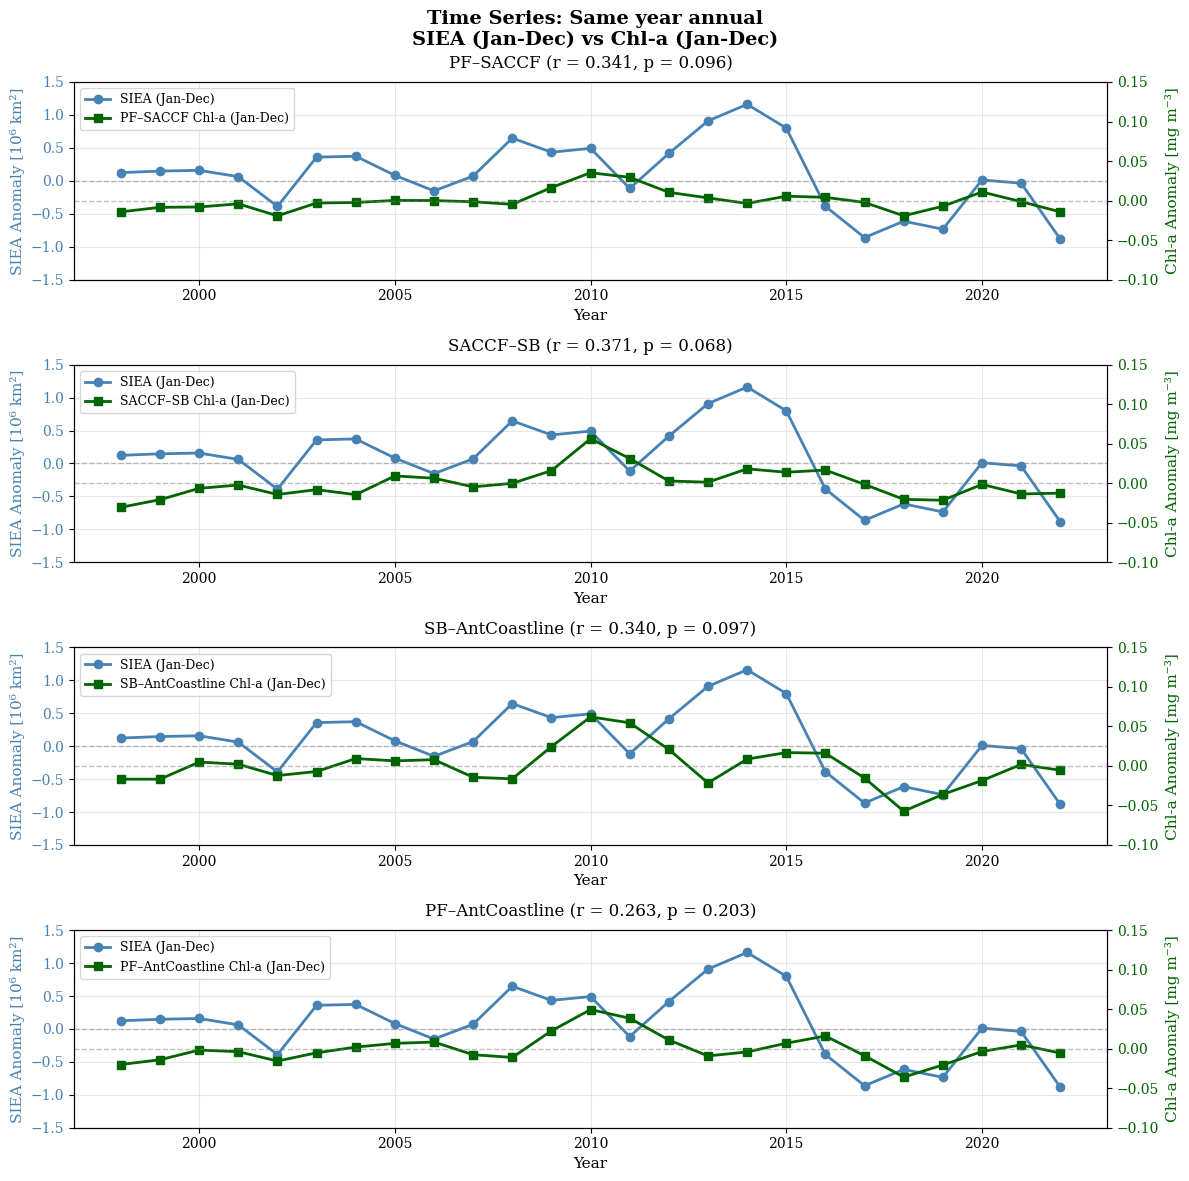

✓ Time series figure created for: Same year annual


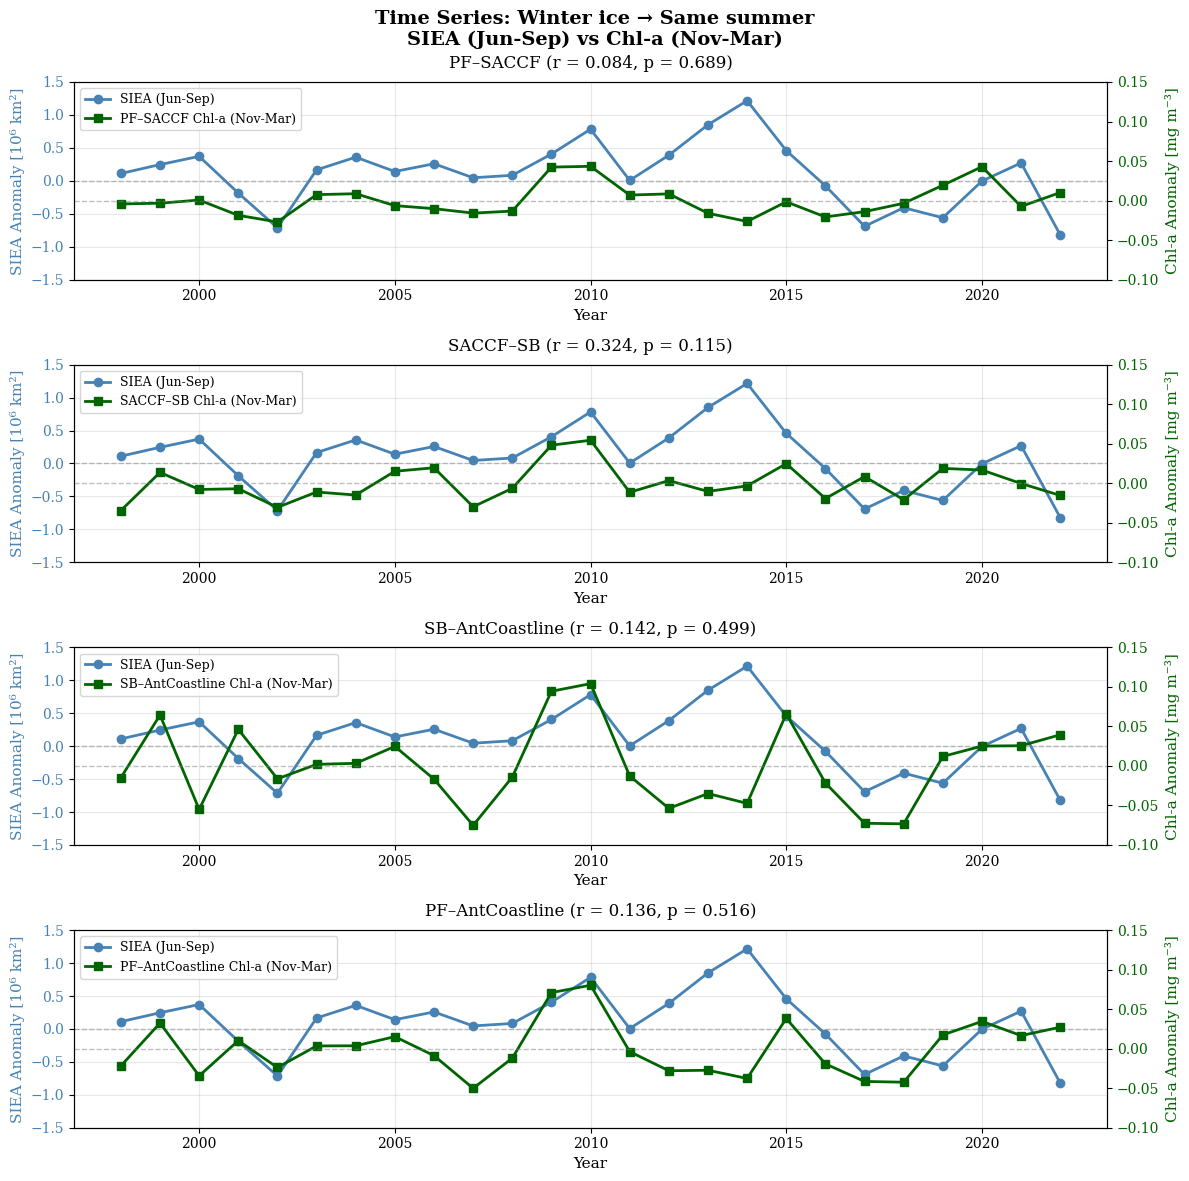

✓ Time series figure created for: Winter ice → Same summer


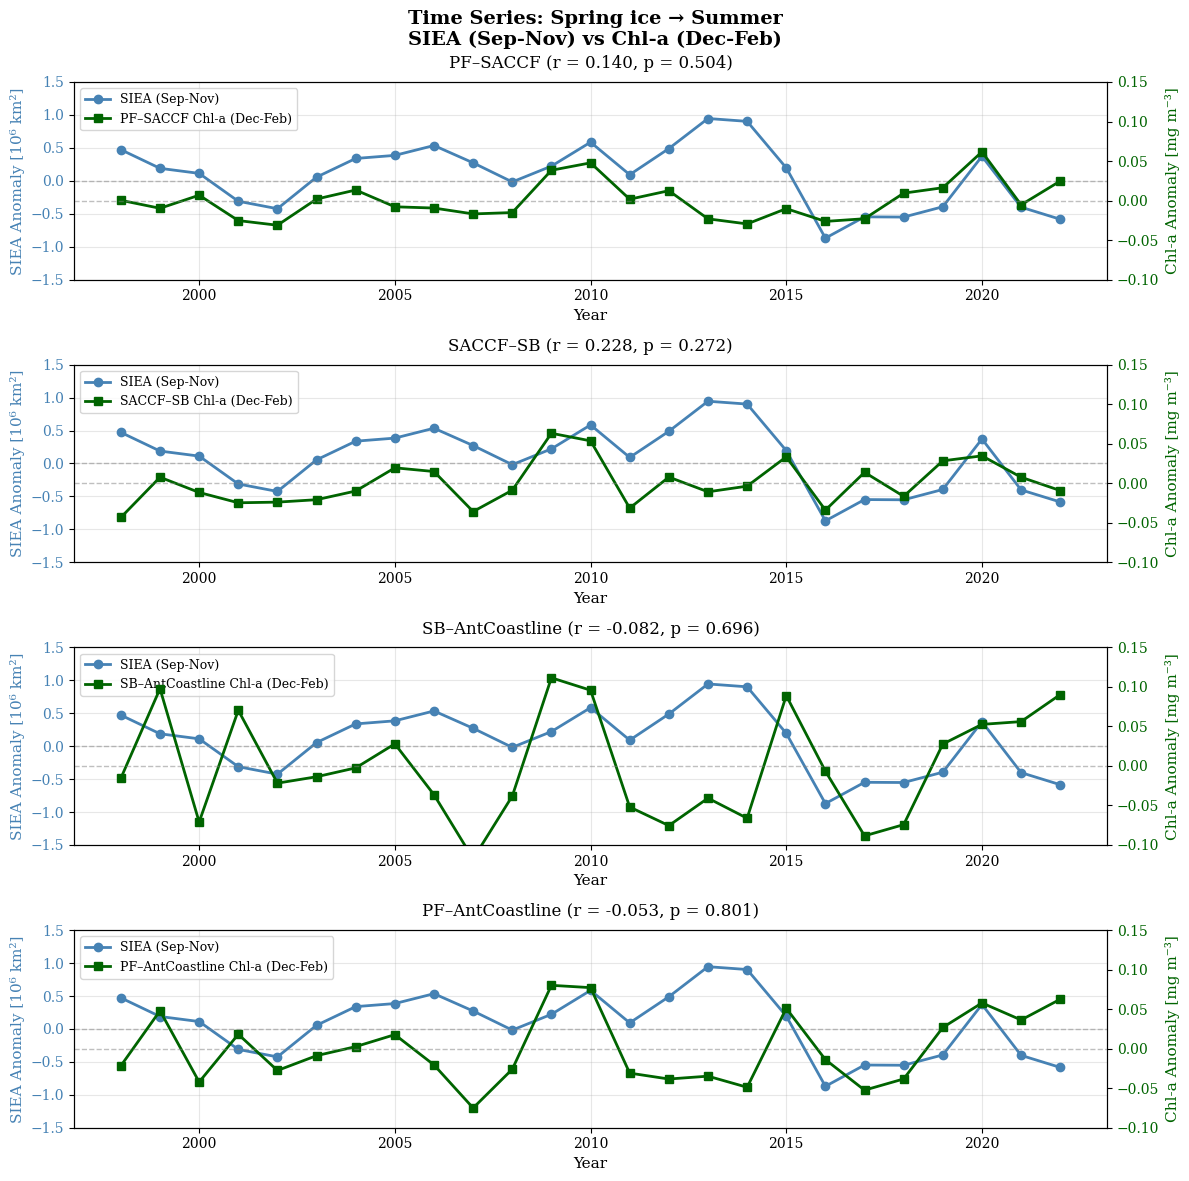

✓ Time series figure created for: Spring ice → Summer


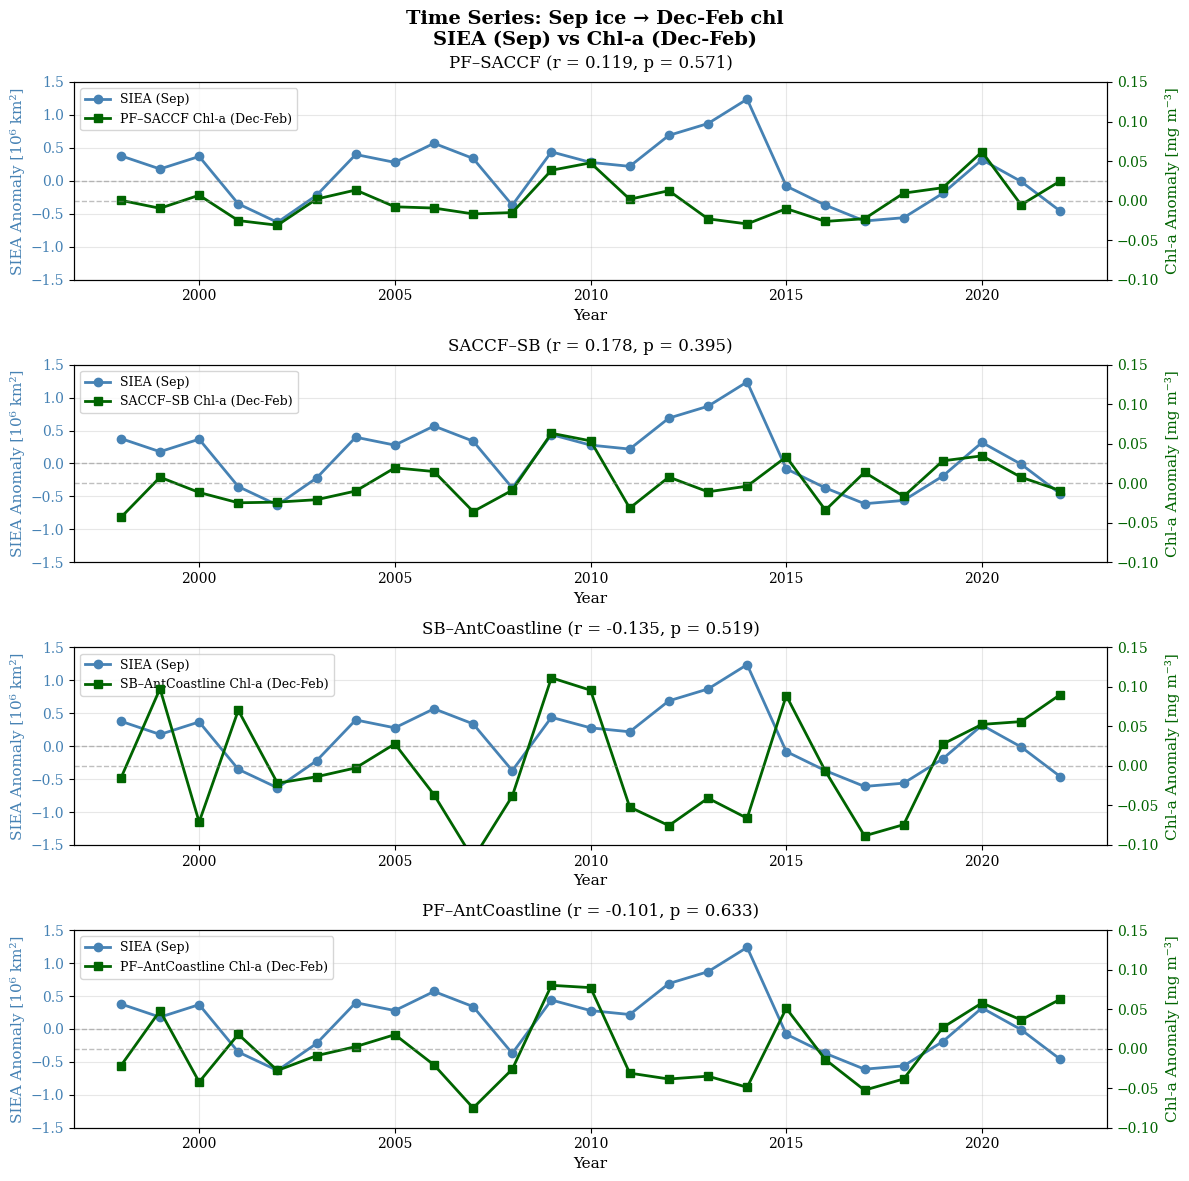

✓ Time series figure created for: Sep ice → Dec-Feb chl


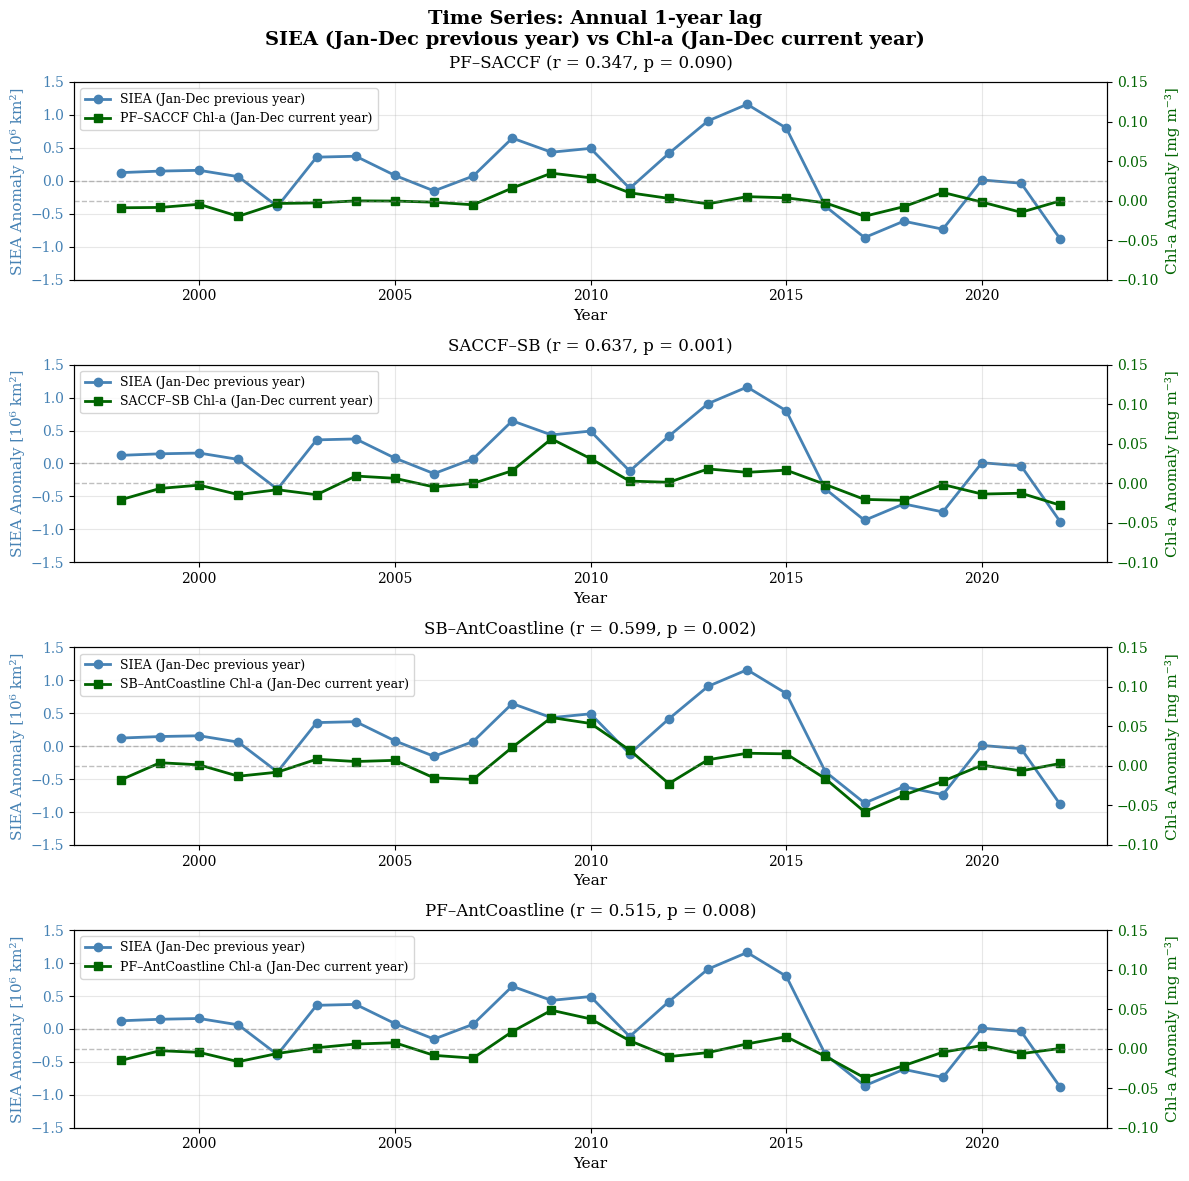

✓ Time series figure created for: Annual 1-year lag


In [61]:
# Time series visualization for the 4 lag structures
# Create 4 separate figures, each with 3 subplots (one per region)

lag_structures_for_ts = {
    'Same year annual': {
        'siea_months': (1, 12),
        'chla_months': (1, 12),
        'chla_year_offset': 0,
        'siea_label': 'SIEA (Jan-Dec)',
        'chla_label': 'Chl-a (Jan-Dec)'
    },
    'Winter ice → Same summer': {
        'siea_months': (6, 9),
        'chla_months': (11, 3),
        'chla_year_offset': 0,
        'siea_label': 'SIEA (Jun-Sep)',
        'chla_label': 'Chl-a (Nov-Mar)'
    },
    'Spring ice → Summer': {
        'siea_months': (9, 11),
        'chla_months': (12, 2),
        'chla_year_offset': 0,
        'siea_label': 'SIEA (Sep-Nov)',
        'chla_label': 'Chl-a (Dec-Feb)'
    },
    'Sep ice → Dec-Feb chl': {
        'siea_months': (9, 9),
        'chla_months': (12, 2),
        'chla_year_offset': 0,
        'siea_label': 'SIEA (Sep)',
        'chla_label': 'Chl-a (Dec-Feb)'
    },
    # lag structure for annual 1y lag to SIEA (siea_months': (1, 12) from previous year and chla_months': (1, 12) from current year)
    'Annual 1-year lag': {
        'siea_months': (1, 12),
        'chla_months': (1, 12),
        'chla_year_offset': 1,
        'siea_label': 'SIEA (Jan-Dec previous year)',
        'chla_label': 'Chl-a (Jan-Dec current year)'
    }
}

for lag_name, lag_config in lag_structures_for_ts.items():
    # Get data for this lag structure
    lag_data = create_lag_structure_data(sie, chl, lag_config, regions_to_analyze)
    
    # Calculate correlations for this lag structure
    lag_correlations = {}
    for region in regions_to_analyze:
        x = lag_data['siea_anomaly'].values
        y = lag_data[f'{region}_anomaly'].values
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() > 3:
            r, p = stats.pearsonr(x[mask], y[mask])
            lag_correlations[region] = {'r': r, 'p': p}
    
    # Create time series plot
    fig, axes = plt.subplots(4, 1, figsize=(12, 12))
    fig.suptitle(f'Time Series: {lag_name}\n{lag_config["siea_label"]} vs {lag_config["chla_label"]}', 
                 fontsize=14, fontweight='bold')
    
    years = lag_data['year'].values
    
    for idx, region in enumerate(regions_to_analyze):
        ax = axes[idx]
        
        # Plot SIEA on left y-axis
        ax1 = ax
        color1 = 'steelblue'
        ax1.plot(years, lag_data['siea_anomaly'], 'o-', color=color1, 
                linewidth=2, markersize=6, label=lag_config['siea_label'])
        ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax1.set_xlabel('Year', fontsize=11)
        ax1.set_ylabel('SIEA Anomaly [10⁶ km²]', fontsize=11, color=color1)
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(-1.5, 1.5)
        
        # Plot chl-a on right y-axis
        ax2 = ax1.twinx()
        color2 = 'darkgreen'
        ax2.plot(years, lag_data[f'{region}_anomaly'], 's-', color=color2, 
                linewidth=2, markersize=6, label=f'{regions_labels[region]} {lag_config["chla_label"]}')
        ax2.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax2.set_ylabel('Chl-a Anomaly [mg m⁻³]', fontsize=11, color=color2)
        ax2.tick_params(axis='y', labelcolor=color2)
        ax2.set_ylim(-0.1, 0.15)
        # Title with correlation
        if region in lag_correlations:
            r = lag_correlations[region]['r']
            p = lag_correlations[region]['p']
            ax.set_title(f'{regions_labels[region]} (r = {r:.3f}, p = {p:.3f})', 
                        fontsize=12, pad=10)
        else:
            ax.set_title(f'{regions_labels[region]}', fontsize=12, pad=10)
        
        # Combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    print(f"✓ Time series figure created for: {lag_name}")

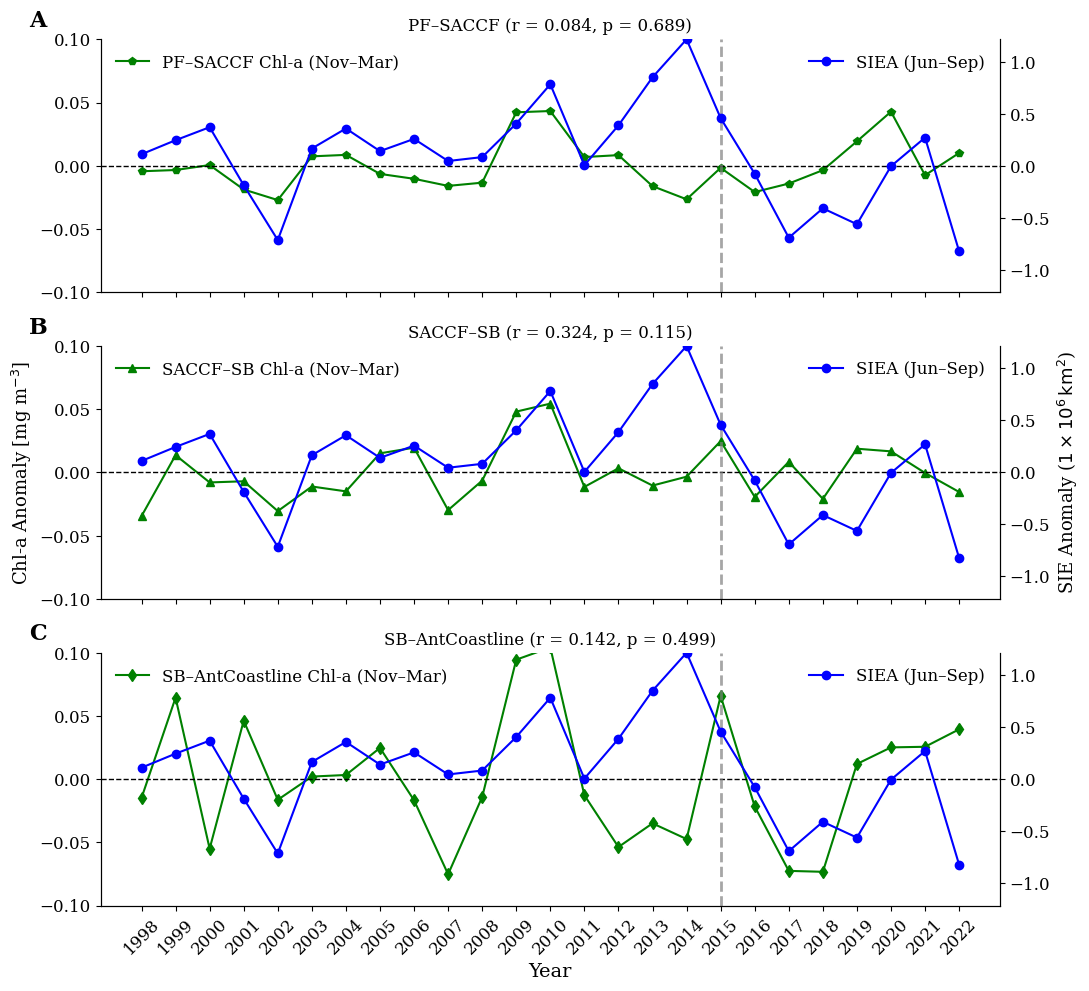

✓ Winter ice (Jun–Sep → Nov–Mar) figure created successfully


In [62]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# -----------------------------
# Select ONLY winter ice lag
# -----------------------------
lag_config = {
    'siea_months': (6, 9),
    'chla_months': (11, 3),
    'chla_year_offset': 0,
    'siea_label': 'SIEA (Jun–Sep)',
    'chla_label': 'Chl-a (Nov–Mar)'
}

# Create lagged dataset
lag_data = create_lag_structure_data(sie, chl, lag_config, regions_to_analyze)

# Calculate correlations
lag_correlations = {}
for region in regions_to_analyze:
    x = lag_data['siea_anomaly'].values
    y = lag_data[f'{region}_anomaly'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() > 3:
        r, p = stats.pearsonr(x[mask], y[mask])
        lag_correlations[region] = {'r': r, 'p': p}

# -----------------------------
# Create 3-panel styled figure
# -----------------------------
years = lag_data['year'].values
regions_3 = regions_to_analyze[:3]
panel_labels = ['A', 'B', 'C']
markers = ['p', '^', 'd']

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

for i, (ax, region, panel_label, marker) in enumerate(
        zip(axes, regions_3, panel_labels, markers)):

    # -------- LEFT AXIS (Chl-a) --------
    ax.plot(
        years,
        lag_data[f'{region}_anomaly'],
        marker=marker,
        linestyle='-',
        color='green',
        linewidth=1.5,
        markersize=6,
        label=f'{regions_labels[region]} {lag_config["chla_label"]}'
    )
    
    ax.set_ylim(-0.1, 0.1)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(2015, color='grey', linestyle='--',
               linewidth=2, alpha=0.7)

    ax.spines['top'].set_visible(False)

    ax.text(-0.08, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=16, fontweight='bold')

    if i == 1:
        ax.set_ylabel('Chl-a Anomaly [mg m$^{-3}$]', fontsize=13)

    ax.tick_params(axis='y', labelsize=12)

    # -------- RIGHT AXIS (SIEA) --------
    ax2 = ax.twinx()

    ax2.plot(
        years,
        lag_data['siea_anomaly'],
        marker='o',
        linestyle='-',
        color='blue',
        linewidth=1.5,
        markersize=6,
        label=lag_config['siea_label']
    )

    ax2.spines['top'].set_visible(False)

    if i == 1:
        ax2.set_ylabel(r'SIE Anomaly ($1 \times 10^6 \, \mathrm{km}^2$)',
                       fontsize=13)

    ax2.tick_params(axis='y', labelsize=12)

    # -------- Align zero levels --------
    left_min, left_max = ax.get_ylim()
    zero_fraction = (0 - left_min) / (left_max - left_min)
    zero_fraction = float(np.clip(zero_fraction, 1e-6, 1 - 1e-6))

    right_data = lag_data['siea_anomaly'].to_numpy(dtype=float)
    right_data = right_data[np.isfinite(right_data)]

    if right_data.size:
        right_min = np.nanmin(right_data)
        right_max = np.nanmax(right_data)
        span = max(right_max / (1 - zero_fraction),
                   -right_min / zero_fraction)

        ax2.set_ylim(-zero_fraction * span,
                     (1 - zero_fraction) * span)

    # -------- Correlation title --------
    if region in lag_correlations:
        r = lag_correlations[region]['r']
        p = lag_correlations[region]['p']
        ax.set_title(f'{regions_labels[region]} (r = {r:.3f}, p = {p:.3f})',
                     fontsize=12)

    # Legends
    ax.legend(loc='upper left', fontsize=12, frameon=False)
    ax2.legend(loc='upper right', fontsize=12, frameon=False)

# -------- Force all years to show --------
axes[-1].set_xticks(years)
axes[-1].set_xticklabels(years, rotation=45, fontsize=12)
axes[-1].set_xlabel('Year', fontsize=14)

plt.tight_layout()
plt.show()

print("✓ Winter ice (Jun–Sep → Nov–Mar) figure created successfully")

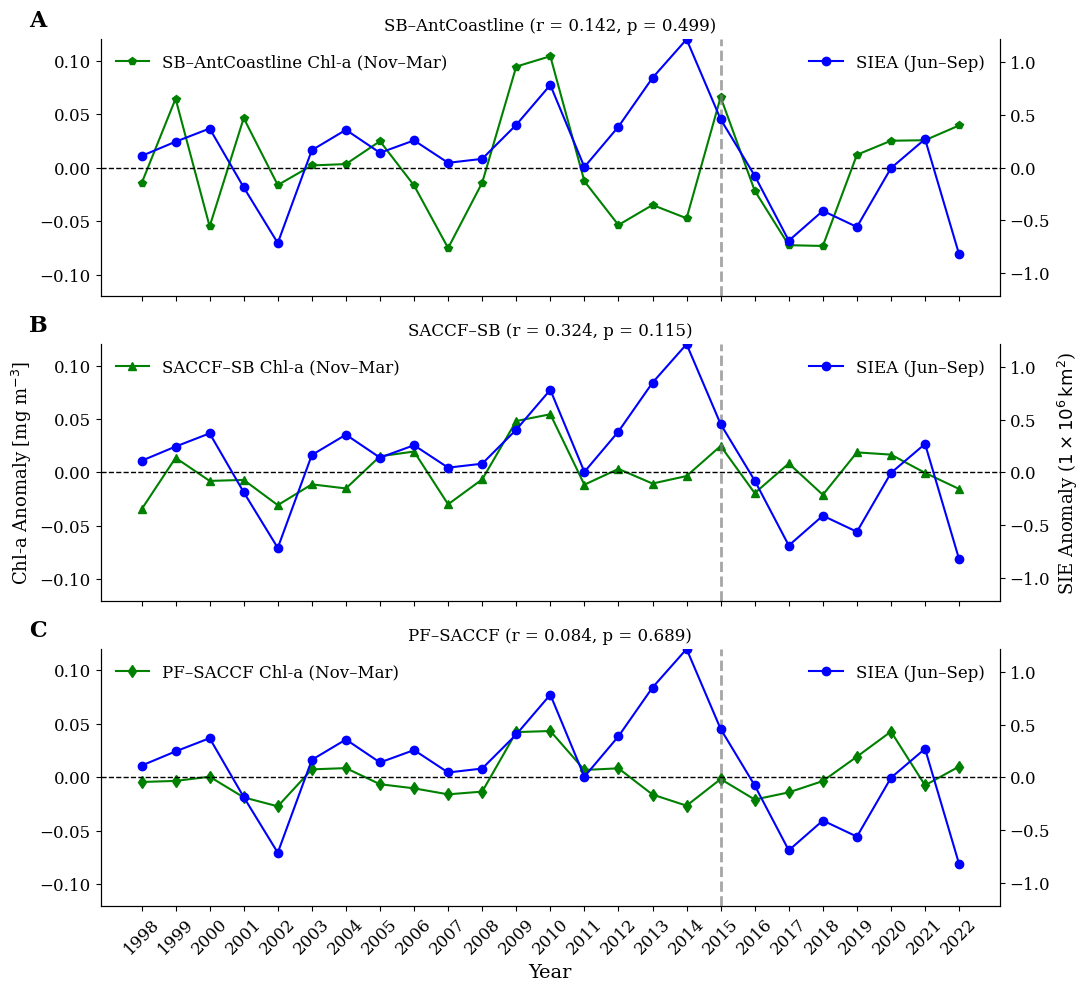

✓ Winter ice (Jun–Sep → Nov–Mar) figure created successfully


In [63]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
plt.rcParams["font.family"] = "serif"
# -----------------------------
# Select ONLY winter ice lag
# -----------------------------
lag_config = {
    'siea_months': (6, 9),
    'chla_months': (11, 3),
    'chla_year_offset': 0,
    'siea_label': 'SIEA (Jun–Sep)',
    'chla_label': 'Chl-a (Nov–Mar)'
}

# Create lagged dataset
lag_data = create_lag_structure_data(sie, chl, lag_config, regions_to_analyze)

# -----------------------------
# FORCE REGION ORDER (IMPORTANT)
# -----------------------------
regions_3 = [
    'SB_AntCoastline',
    'SACCF_SB',
    'PF_SACCF'
]
panel_labels = ['A', 'B', 'C']
markers = ['p', '^', 'd']

# -----------------------------
# Calculate correlations
# -----------------------------
lag_correlations = {}
for region in regions_3:
    x = lag_data['siea_anomaly'].values
    y = lag_data[f'{region}_anomaly'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() > 3:
        r, p = stats.pearsonr(x[mask], y[mask])
        lag_correlations[region] = {'r': r, 'p': p}

# -----------------------------
# Create 3-panel figure
# -----------------------------
years = lag_data['year'].values

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

for i, region in enumerate(regions_3):

    ax = axes[i]
    panel_label = panel_labels[i]
    marker = markers[i]

    # -------- LEFT AXIS (Chl-a) --------
    ax.plot(
        years,
        lag_data[f'{region}_anomaly'],
        marker=marker,
        linestyle='-',
        color='green',
        linewidth=1.5,
        markersize=6,
        label=f'{regions_labels[region]} {lag_config["chla_label"]}'
    )

    ax.set_ylim(-0.12, 0.12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(2015, color='grey', linestyle='--', linewidth=2, alpha=0.7)

    ax.spines['top'].set_visible(False)

    ax.text(
        -0.08, 1.05, panel_label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold'
    )

    if i == 1:
        ax.set_ylabel('Chl-a Anomaly [mg m$^{-3}$]', fontsize=13)

    ax.tick_params(axis='y', labelsize=12)

    # -------- RIGHT AXIS (SIEA) --------
    ax2 = ax.twinx()

    ax2.plot(
        years,
        lag_data['siea_anomaly'],
        marker='o',
        linestyle='-',
        color='blue',
        linewidth=1.5,
        markersize=6,
        label=lag_config['siea_label']
    )

    ax2.spines['top'].set_visible(False)

    if i == 1:
        ax2.set_ylabel(
            r'SIE Anomaly ($1 \times 10^6 \, \mathrm{km}^2$)',
            fontsize=13
        )

    ax2.tick_params(axis='y', labelsize=12)

    # -------- Align zero levels --------
    left_min, left_max = ax.get_ylim()
    zero_fraction = (0 - left_min) / (left_max - left_min)
    zero_fraction = float(np.clip(zero_fraction, 1e-6, 1 - 1e-6))

    right_data = lag_data['siea_anomaly'].to_numpy(dtype=float)
    right_data = right_data[np.isfinite(right_data)]

    if right_data.size:
        right_min = np.nanmin(right_data)
        right_max = np.nanmax(right_data)

        span = max(
            right_max / (1 - zero_fraction),
            -right_min / zero_fraction
        )

        ax2.set_ylim(
            -zero_fraction * span,
            (1 - zero_fraction) * span
        )

    # -------- Correlation title --------
    if region in lag_correlations:
        r = lag_correlations[region]['r']
        p = lag_correlations[region]['p']
        ax.set_title(
            f'{regions_labels[region]} (r = {r:.3f}, p = {p:.3f})',
            fontsize=12
        )

    # Legends
    ax.legend(loc='upper left', fontsize=12, frameon=False)
    ax2.legend(loc='upper right', fontsize=12, frameon=False)

# -----------------------------
# X-axis formatting
# -----------------------------
axes[-1].set_xticks(years)
axes[-1].set_xticklabels(years, rotation=45, fontsize=12)
axes[-1].set_xlabel('Year', fontsize=14)
plt.tight_layout()
plt.show()

print("✓ Winter ice (Jun–Sep → Nov–Mar) figure created successfully")